In [25]:
from data_loader import hourly_data_loader
df = hourly_data_loader()

print(f'Available Features:')
print(df.columns.to_list())

Available Features:
['time', 'kwh', 'temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'hour', 'dayofweek', 'month', 'is_weekend', 'awake', 'evening', 'temp_lag1', 'temp_lag3', 'temp_lag6', 'temp_avg_12', 'rhum_lag3', 'prcp_sum_12', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'wdir_sin', 'wdir_cos']


In [26]:
WINDOW = 6  # look back x hours

FEATURE_COLS = [
    'temp',
    'rhum', 
    'prcp', 
    'wspd', 
    'wdir_sin',
    'wdir_cos',
    #'temp_lag1', 
    #'temp_lag3', 
    #'temp_lag6',
    'temp_avg_12',
    #'rhum_lag3',
    'prcp_sum_12',
    'awake',
    'is_weekend',
    'evening',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    ]

In [27]:
import numpy as np
from sklearn.preprocessing import StandardScaler


X_data = df[FEATURE_COLS].values
y_data = df['kwh'].values.reshape(-1, 1)  # Reshape required for scaling

split_idx = int(len(X_data) * 0.75)

scaler_X = StandardScaler()
scaler_X.fit(X_data[:split_idx])          # Learn the math from the past
X_scaled = scaler_X.transform(X_data)     # Apply the math to the whole timeline

scaler_y = StandardScaler()
scaler_y.fit(y_data[:split_idx])
y_scaled = scaler_y.transform(y_data)

# Build sliding windows
X_windows = []
y_targets = []

for i in range(WINDOW, len(X_scaled)):
    X_windows.append(X_scaled[i-WINDOW:i])  
    y_targets.append(y_scaled[i, 0])

X_windows = np.array(X_windows)  # Shape: (n_samples, 6, n_features)
y_targets = np.array(y_targets)  # Shape: (n_samples,1)

X_train = X_windows[:split_idx - WINDOW]
X_test  = X_windows[split_idx - WINDOW:]
y_train = y_targets[:split_idx - WINDOW]
y_test  = y_targets[split_idx - WINDOW:]


In [28]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# No permute needed — LSTM expects (batch, seq_len, features)
X_train_t = torch.tensor(X_train, dtype=torch.float32)  # (n, 24, 7)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

# Model
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden_size=16, num_layers=2, batch_first = True, dropout=0.05):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers, 
                           batch_first=batch_first, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x shape: (batch, seq_len, n_features)
        out, (h, c) = self.lstm(x)
        return self.fc(out[:, -1, :])  # use last timestep's output

In [51]:
model = LSTMModel(n_features=len(FEATURE_COLS), dropout=.2, hidden_size=16, num_layers=1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
criterion = nn.HuberLoss()

train_losses = []
test_losses = []

n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        pred = model(Xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()
    test_losses.append(test_loss)
    #scheduler.step(test_loss)
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1:3d} | Test MSE: {test_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")


c:\Users\NickGarfield\AppData\Local\pypoetry\Cache\virtualenvs\neuralnets-project-kU7xEBzW-py3.11\Lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Epoch   5 | Test MSE: 0.2584 | LR: 0.000100
Epoch  10 | Test MSE: 0.2496 | LR: 0.000100
Epoch  15 | Test MSE: 0.2435 | LR: 0.000100
Epoch  20 | Test MSE: 0.2411 | LR: 0.000100


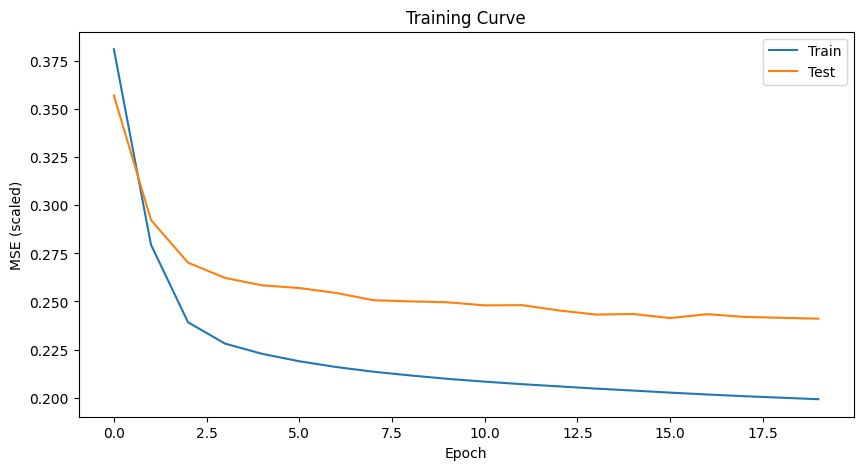

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.title('Training Curve')
plt.show()

MLP: R²=0.518  RMSE=0.97 kWh  MAE=0.68


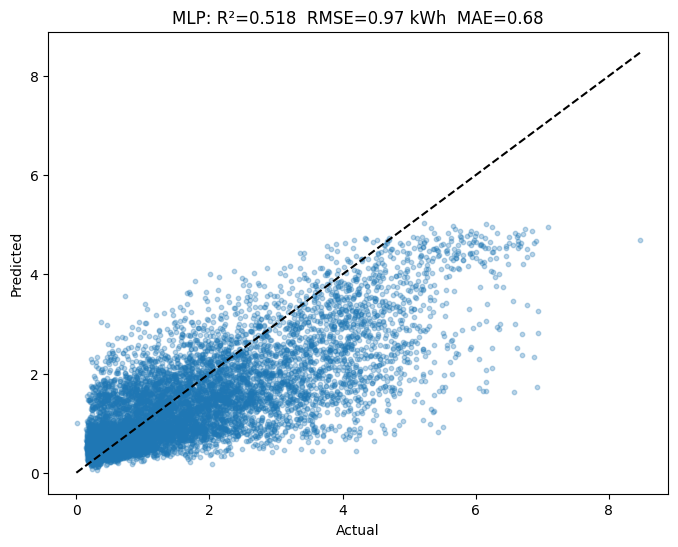

In [53]:
import numpy as np

model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).numpy()
    pred_kwh = scaler_y.inverse_transform(pred_scaled)
    test_kwh = scaler_y.inverse_transform(y_test_t)
    
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test_kwh, pred_kwh))
r2 = r2_score(test_kwh, pred_kwh)
mae = mean_absolute_error(test_kwh, pred_kwh)

plt.figure(figsize=(8, 6))
plt.scatter(test_kwh, pred_kwh, alpha=0.3, s=10)
plt.plot([0, test_kwh.max()], [0, test_kwh.max()], 'k--')  # perfect prediction line
plt.xlabel('Actual')
plt.ylabel('Predicted')

print(f'MLP: R²={r2:.3f}  RMSE={rmse:.2f} kWh  MAE={mae:.2f}')
plt.title(f'MLP: R²={r2:.3f}  RMSE={rmse:.2f} kWh  MAE={mae:.2f}')
plt.show()